In [2]:
from google.colab import files
uploaded = files.upload()

Saving Salary Data.csv to Salary Data.csv


In [3]:
import pandas as pd
import numpy as np


In [4]:
df=pd.read_csv('/content/Salary Data.csv')

In [5]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [7]:
df.shape

(375, 6)

In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Education Level']=le.fit_transform(df['Education Level'])
df['Job Title']=le.fit_transform(df['Job Title'])

In [10]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,0,0,131,8.0,85000.0
371,43.0,1,1,30,19.0,170000.0
372,29.0,0,0,70,2.0,40000.0
373,34.0,1,0,137,7.0,90000.0


In [11]:
df.isnull().sum()

,0
Age,2
Gender,0
Education Level,0
Job Title,0
Years of Experience,2
Salary,2


In [16]:
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=3)
df['Age']=imputer.fit_transform(df[['Age']])
df['Years of Experience']=imputer.fit_transform(df[['Years of Experience']])
df['Salary']=imputer.fit_transform(df[['Salary']])

In [17]:
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


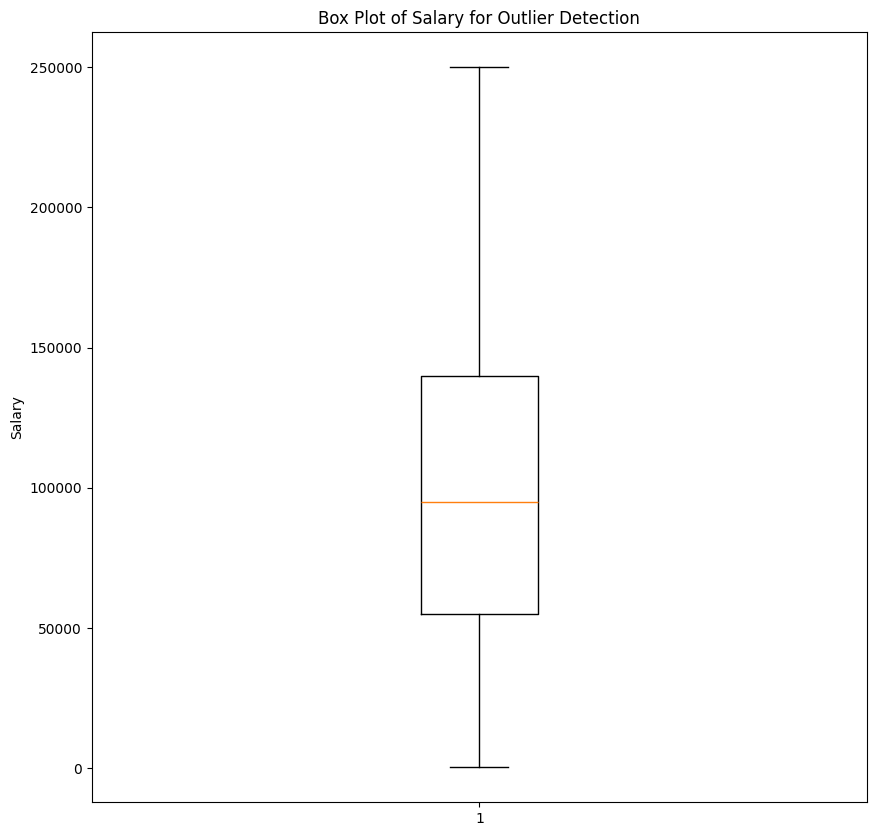

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.boxplot(df['Salary'])
plt.title('Box Plot of Salary for Outlier Detection')
plt.ylabel('Salary')
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['Age']=sc.fit_transform(df[['Age']])
df['Years of Experience']=sc.fit_transform(df[['Years of Experience']])
df['Salary']=sc.fit_transform(df[['Salary']])

In [24]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,-0.771458,1,0,159,-0.770333,-0.220147
1,-1.339580,0,1,17,-1.076577,-0.740475
2,1.074939,1,2,130,0.760891,1.028639
3,-0.203336,0,0,101,-0.464088,-0.844540
4,2.069153,1,1,22,1.526502,2.069294
...,...,...,...,...,...,...
370,-0.345366,0,0,131,-0.310966,-0.324213
371,0.790878,1,1,30,1.373380,1.444901
372,-1.197550,0,0,70,-1.229700,-1.260802
373,-0.487397,1,0,137,-0.464088,-0.220147


In [25]:
x=df.drop('Salary',axis=1)
y=df['Salary']

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
param_grid={'fit_intercept':[True,False],'copy_X':[True,False]}
grid=GridSearchCV(LinearRegression(),param_grid, refit = True, verbose = 5,n_jobs=-1,scoring='r2')
grid.fit(x_train,y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(estimator=LinearRegression(), n_jobs=-1,
             param_grid={'copy_X': [True, False],
                         'fit_intercept': [True, False]},
             scoring='r2', verbose=5)

In [58]:
gv=grid.predict(x_test)
gv

array([ 1.50512858, -0.12785892,  0.65544114, -0.36502578,  1.22434056,
        1.77838839,  1.2341581 ,  0.05427782, -0.90826955, -0.00510604,
        0.83511726,  1.2605595 , -1.03946323, -0.23672791, -0.78710264,
        1.24417362, -0.6734103 , -1.10729658, -0.45113002, -0.07785254,
        0.55513063,  0.12240873,  1.30249824, -0.80562586, -0.24235957,
       -1.06564415,  1.5852891 ,  0.95462331,  1.15465469,  0.97616094,
       -1.18783985,  0.52736375, -0.96444558,  1.05596515, -0.23514194,
       -1.72788391,  1.69969763, -1.04304422, -1.31573359, -0.87264278,
       -1.1648294 , -0.26376031,  1.45781022,  1.32436368, -1.20338153,
        1.1338476 ,  0.42254192, -1.01249193, -1.08632869, -1.34235547,
        0.04406012, -0.42123283, -0.47180183,  0.08694679,  1.30094963,
       -0.73164281,  1.83871384, -0.47273851, -1.1077167 , -0.34341729,
        0.37558345,  0.80005312,  1.24751583, -0.78728576, -1.22959981,
       -1.09523566, -0.91328293,  0.58561999, -1.1648294 , -1.44

In [59]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8888191777593426

## Make a Prediction for New Input Data

In [65]:
import pandas as pd

def get_encoded_value(le, user_input, feature_name):

    if user_input in le.classes_:
        return le.transform([user_input])[0]


    possible_inputs = [
        user_input.title(),
        user_input.capitalize(),
        user_input.upper(),
        user_input.lower(),
    ]


    checked_inputs = []
    for pi in possible_inputs:
        if pi not in checked_inputs:
            checked_inputs.append(pi)
            if pi in le.classes_:
                print(f"Using '{pi}' for '{user_input}' (case-adjusted for {feature_name}).")
                return le.transform([pi])[0]

    print(f"⚠️ '{user_input}' not found for {feature_name}. Available options include: {', '.join(le.classes_)}")
    return 0

new_age = int(input("Enter Age: "))
new_gender = input("Enter Gender (Male/Female): ")
new_education = input("Enter Education Level (Bachelor's/Master's/PhD/High School): ")
new_job_title = input("Enter Job Title: ")
new_experience = int(input("Enter Years of Experience: "))

encoded_gender = get_encoded_value(le_gender, new_gender, 'Gender')
encoded_education = get_encoded_value(le_education, new_education, 'Education Level')
encoded_jobtitle = get_encoded_value(le_jobtitle, new_job_title, 'Job Title')



scaled_age = sc_age.transform(pd.DataFrame([[new_age]], columns=['Age']))[0][0]
scaled_exp = sc_exp.transform(pd.DataFrame([[new_experience]], columns=['Years of Experience']))[0][0]



input_data = pd.DataFrame([[scaled_age, encoded_gender, encoded_education,
                             encoded_jobtitle, scaled_exp]],
                           columns=['Age', 'Gender', 'Education Level',
                                    'Job Title', 'Years of Experience'])

predicted_scaled = grid.predict(input_data)[0]

predicted_salary = sc_salary.inverse_transform([[predicted_scaled]])[0][0]


print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("       SALARY PREDICTION     ")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  Age             : {new_age}")
print(f"  Gender          : {new_gender}")
print(f"  Education       : {new_education}")
print(f"  Job Title       : {new_job_title}")
print(f"  Experience      : {new_experience} years")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  Predicted Salary: ${predicted_salary:,.2f}")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

Enter Age: 25
Enter Gender (Male/Female): male
Enter Education Level (Bachelor's/Master's/PhD/High School): Bachelor's
Enter Job Title: software developer
Enter Years of Experience: 3
Using 'Male' for 'male' (case-adjusted for Gender).
Using 'Software Developer' for 'software developer' (case-adjusted for Job Title).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
       SALARY PREDICTION     
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Age             : 25
  Gender          : male
  Education       : Bachelor's
  Job Title       : software developer
  Experience      : 3 years
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Predicted Salary: $39,986.56
━━━━━━━━━━━━━━━━━━━━━━━━━━━━

